In [ ]:
######## Notes:added neural prediction on top of v5 version

In [4]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate  
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    roc_auc_score,
    precision_score,
    f1_score
)

In [3]:
# File path
file_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_02_processed_final.csv"

# Load the file
df = pd.read_csv(file_path)

# Find columns that contain "time" (case-insensitive)
time_cols = [col for col in df.columns if "time" in col.lower()]

# Print them
print(f"Columns containing 'time' or 'Time' ({len(time_cols)} found):")
for col in time_cols:
    print(f"- {col}")


Columns containing 'time' or 'Time' (2 found):
- Time (s)
- condition time stamps


In [16]:
########## Revision v6: cross validation plus train-test split, neural Only
# Define directories
# Need to modify output_dir, permute_y, target_variable
input_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final"
os.makedirs(output_dir, exist_ok=True)

# Configuration
permute_y = False  # Set to False for normal classification
random_state = 12  # For reproducibility
cv_folds = 10     # Number of cross-validation folds

# Determine report type
if permute_y:
    report_type = "permutation_reports"
    permutation_label = "permutation"
else:
    report_type = "classification_reports"
    permutation_label = "original"
    
# Store evaluation metrics
cv_metrics = []       # For cross-validation results
test_metrics = []     # For final test results
weights_data = []      # To store weights for all participants

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Variables to predict
target_variable = "q2_y"
excluded_columns = ["q1_y", "q2_y", "q3_y", "q4_y", "stimID","Time (s)","Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"] #be careful about the space in the time variable
special_columns = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]

#############################################################
# Loop through all files in the folder
for file_name in os.listdir(input_dir):
    if file_name.endswith(".csv"):
        file_path = os.path.join(input_dir, file_name)
        print(f"\nProcessing file: {file_name}")
        
    # Load data
    df = pd.read_csv(file_path, dtype={target_variable: str})
    participant_id = file_name.split('.')[0]  # Extract participant number
    
    print(f"Initial shape of data for participant {participant_id}: {df.shape}")
    
    # # Convert any cell containing 'F' in specified columns to 0
    # for col in special_columns:
    #     if col in df.columns:
    #         df[col] = df[col].apply(lambda x: 0 if isinstance(x, str) and 'F' in x else (x if isinstance(x, (int, float)) else 0))

    # Convert categorical labels to numeric
    y = df[target_variable].replace({
        "long_happy": 4, "long_sad": 3, "fixation": 2,
        "emotional": 1, "neutral": 0, "Emotional": 1, "Neutral": 0
    })
    
    # Keep only data where y is 1 (emotional) or 0 (neutral)
    mask = (y == 1) | (y == 0)
    X = df.drop(columns=excluded_columns)[mask]
    y = y[mask]
    
    # Check if there is enough data to proceed
    if y.nunique() < 2:
        print(f"Warning: Not enough data for classification after filtering. Skipping participant {participant_id}.")
        continue
        
    # Convert to integer
    y = y.astype(int)
    
    # Train-test split (80-20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)
    
    # If permutation is enabled, shuffle the y labels
    if permute_y:
        np.random.seed(random_state)
        y_train = np.random.permutation(y_train.values)
        y_test = np.random.permutation(y_test.values)
        
    print(f"Training data shape: {X_train.shape}, Testing data shape: {X_test.shape}")
    
    # Define ML pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', random_state=random_state))
    ])
    
    # Perform 10-fold cross-validation on training set
    print("\nPerforming 10-fold cross-validation...")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        pipeline, 
        X_train, 
        y_train,
        cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    # Store CV metrics
    cv_metrics.append({
        'Participant': participant_id,
        'CV_Accuracy_Mean': np.mean(cv_results['test_accuracy']),
        'CV_Accuracy_Std': np.std(cv_results['test_accuracy']),
        'CV_Balanced_Accuracy_Mean': np.mean(cv_results['test_balanced_accuracy']),
        'CV_F1_Mean': np.mean(cv_results['test_f1']),
        'CV_ROC_AUC_Mean': np.mean(cv_results['test_roc_auc'])
    })

    # Train final model on entire training set
    print("\nTraining final model on full training set...")
    pipeline.fit(X_train, y_train)
    
    # Get feature weights
    svm = pipeline.named_steps['svm']
    weights_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Weight': svm.coef_[0],
        'Absolute_Weight': np.abs(svm.coef_[0]),
        'Participant': participant_id
    })
    weights_data.append(weights_df)
    
    # Evaluate on test set
    y_pred = pipeline.predict(X_test)
    test_report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store test metrics
    for label, metrics in test_report.items():
        if isinstance(metrics, dict):
            test_metrics.append({
                'Participant': participant_id,
                'Dataset': 'test',  # Explicitly mark as test set results
                'Class': label,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1': metrics['f1-score'],
                'Support': metrics['support'],
                'Accuracy': test_report['accuracy'] if label == '0' else None  # Avoid duplicate accuracy
            })
    
    # Print summary
    print("\nValidation Results:")
    print(f"10-Fold CV Accuracy: {cv_metrics[-1]['CV_Accuracy_Mean']:.3f} ± {cv_metrics[-1]['CV_Accuracy_Std']:.3f}")
    print(f"Test Set Accuracy: {test_report['accuracy']:.3f}")
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_pred))

# Save all metrics to CSV files
cv_metrics_df = pd.DataFrame(cv_metrics)
cv_metrics_path = os.path.join(output_dir, f"cv_metrics_eeg_{target_variable}_{permutation_label}.csv")
cv_metrics_df.to_csv(cv_metrics_path, index=False)
print(f"\nCross-validation metrics saved to {cv_metrics_path}")

test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_path = os.path.join(output_dir, f"test_metrics_eeg_{target_variable}_{permutation_label}.csv")
test_metrics_df.to_csv(test_metrics_path, index=False)
print(f"Test set metrics saved to {test_metrics_path}")

# Save feature weights
if weights_data:
    all_weights_df = pd.concat(weights_data)
    weights_path = os.path.join(output_dir, f"feature_weights_eeg_{target_variable}_{permutation_label}.csv")
    all_weights_df.to_csv(weights_path, index=False)
    print(f"Feature weights saved to {weights_path}")

print("\nAll processing complete!")


Processing file: corrected_11_processed_final.csv
Initial shape of data for participant corrected_11_processed_final: (836, 156)
Training data shape: (427, 141), Testing data shape: (107, 141)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_21024\858170777.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.866 ± 0.055
Test Set Accuracy: 0.850

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72        28
           1       0.91      0.89      0.90        79

    accuracy                           0.85       107
   macro avg       0.80      0.82      0.81       107
weighted avg       0.85      0.85      0.85       107


Processing file: corrected_59_processed_final.csv
Initial shape of data for participant corrected_59_processed_final: (836, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_21024\858170777.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({


Training data shape: (427, 141), Testing data shape: (107, 141)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.822 ± 0.046
Test Set Accuracy: 0.879

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        58
           1       0.91      0.82      0.86        49

    accuracy                           0.88       107
   macro avg       0.88      0.87      0.88       107
weighted avg       0.88      0.88      0.88       107


Processing file: corrected_05_processed_final.csv
Initial shape of data for participant corrected_05_processed_final: (836, 156)
Training data shape: (427, 141), Testing data shape: (107, 141)

Performing 10-fold cross-validation...


...

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.98      0.99       101

    accuracy                           0.98       107
   macro avg       0.88      0.99      0.92       107
weighted avg       0.99      0.98      0.98       107


Processing file: corrected_03_processed_final.csv
Initial shape of data for participant corrected_03_processed_final: (836, 156)
Training data shape: (427, 141), Testing data shape: (107, 141)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_21024\858170777.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.799 ± 0.066
Test Set Accuracy: 0.804

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        57
           1       0.82      0.74      0.78        50

    accuracy                           0.80       107
   macro avg       0.81      0.80      0.80       107
weighted avg       0.81      0.80      0.80       107


Processing file: corrected_21_processed_final.csv
Initial shape of data for participant corrected_21_processed_final: (836, 156)
Training data shape: (427, 141), Testing data shape: (107, 141)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_21024\858170777.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.815 ± 0.061
Test Set Accuracy: 0.766

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        61
           1       0.74      0.70      0.72        46

    accuracy                           0.77       107
   macro avg       0.76      0.76      0.76       107
weighted avg       0.77      0.77      0.77       107


Cross-validation metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\cv_metrics_eeg_q2_y_original.csv
Test set metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_eeg_q2_y_original.csv
Feature weights saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\feature_weights_eeg_q2_y_original.csv

All processing complete!


In [34]:
########## Revision v6: cross validation plus train-test split, facial expression Only
# Define directories
# Need to modify output_dir, permute_y, target_variable
input_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only"
os.makedirs(output_dir, exist_ok=True)

# Configuration
permute_y = True  # Set to False for normal classification
random_state = 12  # For reproducibility
cv_folds = 10     # Number of cross-validation folds

# Determine report type
if permute_y:
    report_type = "permutation_reports"
    permutation_label = "permutation"
else:
    report_type = "classification_reports"
    permutation_label = "original"
    
# Store evaluation metrics
cv_metrics = []
test_metrics = []
weights_data = []

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Variables to predict
target_variable = "q3_y"
included_columns = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]

label_map = {
    "long_happy": 4, "long_sad": 3, "fixation": 2,
    "emotional": 1, "neutral": 0, "Emotional": 1, "Neutral": 0
}

for file_name in os.listdir(input_dir):
    if not file_name.endswith(".csv"):
        continue

    file_path = os.path.join(input_dir, file_name)
    participant_id = os.path.splitext(file_name)[0]
    print(f"\nProcessing file: {file_name}")

    # Load data
    df = pd.read_csv(file_path, dtype={target_variable: str})
    print(f"Initial shape of data for participant {participant_id}: {df.shape}")

    # Labels -> numeric, then keep only {0,1}
    y_raw = df[target_variable].map(label_map)
    mask = y_raw.isin([0, 1])

    # Guard for missing feature columns
    features = [c for c in included_columns if c in df.columns]
    if not features:
        print(f"  Skipping {participant_id}: no requested feature columns present.")
        continue

    # Clean feature columns
    df[features] = df[features].replace("FIT_FAILED", np.nan)

    # Build X/y
    X = df.loc[mask, features].apply(pd.to_numeric, errors="coerce")
    y = y_raw.loc[mask].astype(int)

    # Drop rows where all features are NaN
    all_nan = X.isna().all(axis=1)
    if all_nan.any():
        X = X.loc[~all_nan]
        y = y.loc[~all_nan]

    # Check class balance/size
    if y.nunique() < 2 or len(y) < 3:
        print(f"  Skipping {participant_id}: not enough data for classification after cleaning.")
        continue

    # Train-test split (80-20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # If permutation is enabled, shuffle the y labels
    if permute_y:
        rng = np.random.RandomState(random_state)
        y_train = pd.Series(rng.permutation(y_train.values), index=y_train.index)

    print(f"Training data shape: {X_train.shape}, Testing data shape: {X_test.shape}")

    # Define ML pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', random_state=random_state))
    ])

    # ---- Cross-validation with dynamic folds to avoid n_splits errors ----
    min_class_size = y_train.value_counts().min()
    n_splits = max(2, min(cv_folds, int(min_class_size)))  # at least 2 folds
    if n_splits < 2:
        print(f"  Skipping CV for {participant_id}: too few samples per class.")
        continue

    print(f"\nPerforming {n_splits}-fold cross-validation...")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1', 'roc_auc'],
        return_train_score=False,
        error_score=np.nan
    )

    
    # Store CV metrics
    cv_metrics.append({
        'Participant': participant_id,
        'CV_Accuracy_Mean': np.mean(cv_results['test_accuracy']),
        'CV_Accuracy_Std': np.std(cv_results['test_accuracy']),
        'CV_Balanced_Accuracy_Mean': np.mean(cv_results['test_balanced_accuracy']),
        'CV_F1_Mean': np.mean(cv_results['test_f1']),
        'CV_ROC_AUC_Mean': np.mean(cv_results['test_roc_auc'])
    })

    # Train final model on entire training set
    print("\nTraining final model on full training set...")
    pipeline.fit(X_train, y_train)
    
    # Get feature weights
    svm = pipeline.named_steps['svm']
    weights_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Weight': svm.coef_[0],
        'Absolute_Weight': np.abs(svm.coef_[0]),
        'Participant': participant_id
    })
    weights_data.append(weights_df)
    
    # Evaluate on test set
    y_pred = pipeline.predict(X_test)
    test_report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store test metrics
    for label, metrics in test_report.items():
        if isinstance(metrics, dict):
            test_metrics.append({
                'Participant': participant_id,
                'Dataset': 'test',  # Explicitly mark as test set results
                'Class': label,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1': metrics['f1-score'],
                'Support': metrics['support'],
                'Accuracy': test_report['accuracy'] if label == '0' else None  # Avoid duplicate accuracy
            })
    
    # Print summary
    print("\nValidation Results:")
    print(f"10-Fold CV Accuracy: {cv_metrics[-1]['CV_Accuracy_Mean']:.3f} ± {cv_metrics[-1]['CV_Accuracy_Std']:.3f}")
    print(f"Test Set Accuracy: {test_report['accuracy']:.3f}")
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_pred))

# Save all metrics to CSV files
cv_metrics_df = pd.DataFrame(cv_metrics)
cv_metrics_path = os.path.join(output_dir, f"cv_metrics_expression_{target_variable}_{permutation_label}.csv")
cv_metrics_df.to_csv(cv_metrics_path, index=False)
print(f"\nCross-validation metrics saved to {cv_metrics_path}")

test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_path = os.path.join(output_dir, f"test_metrics_expression_{target_variable}_{permutation_label}.csv")
test_metrics_df.to_csv(test_metrics_path, index=False)
print(f"Test set metrics saved to {test_metrics_path}")

# Save feature weights
if weights_data:
    all_weights_df = pd.concat(weights_data)
    weights_path = os.path.join(output_dir, f"feature_weights_expression_{target_variable}_{permutation_label}.csv")
    all_weights_df.to_csv(weights_path, index=False)
    print(f"Feature weights saved to {weights_path}")

print("\nAll processing complete!")


Processing file: corrected_11_processed_final.csv
Initial shape of data for participant corrected_11_processed_final: (836, 156)
Training data shape: (175, 9), Testing data shape: (44, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.543 ± 0.075
Test Set Accuracy: 0.591

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.59      1.00      0.74        26

    accuracy                           0.59        44
   macro avg       0.30      0.50      0.37        44
weighted avg       0.35      0.59      0.44        44


Processing file: corrected_59_processed_final.csv


C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLte

Initial shape of data for participant corrected_59_processed_final: (836, 156)
Training data shape: (424, 9), Testing data shape: (106, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.583 ± 0.030
Test Set Accuracy: 0.557

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.56      0.97      0.71        60
           1       0.33      0.02      0.04        46

    accuracy                           0.56       106
   macro avg       0.45      0.49      0.38       106
weighted avg       0.46      0.56      0.42       106


Processing file: corrected_05_processed_final.csv
Initial shape of data for participant corrected_05_processed_final: (836, 156)
Training data shape: (427, 9), Testing data shape: (107, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.698 ± 0.006

C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLte

Initial shape of data for participant corrected_54_processed_final: (836, 156)
Training data shape: (427, 9), Testing data shape: (107, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.489 ± 0.034
Test Set Accuracy: 0.402

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.28      0.16      0.20        51
           1       0.45      0.62      0.52        56

    accuracy                           0.40       107
   macro avg       0.36      0.39      0.36       107
weighted avg       0.37      0.40      0.37       107


Processing file: corrected_31_processed_final.csv
Initial shape of data for participant corrected_31_processed_final: (836, 156)
Training data shape: (426, 9), Testing data shape: (107, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.615 ± 0.009

...


Validation Results:
10-Fold CV Accuracy: 0.631 ± 0.006
Test Set Accuracy: 0.636

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.64      1.00      0.78        68
           1       0.00      0.00      0.00        39

    accuracy                           0.64       107
   macro avg       0.32      0.50      0.39       107
weighted avg       0.40      0.64      0.49       107


Processing file: corrected_52_processed_final.csv
Initial shape of data for participant corrected_52_processed_final: (836, 156)
Training data shape: (396, 9), Testing data shape: (100, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.548 ± 0.025
Test Set Accuracy: 0.560

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72        56
           1       0.00      0.00      0.00        44


C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLte

Initial shape of data for participant corrected_20_processed_final: (836, 156)
Training data shape: (426, 9), Testing data shape: (107, 9)

Performing 10-fold cross-validation...

Training final model on full training set...


C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLten\mne-python\1.9.0_0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\OLte


Validation Results:
10-Fold CV Accuracy: 0.848 ± 0.010
Test Set Accuracy: 0.850

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.85      1.00      0.92        91

    accuracy                           0.85       107
   macro avg       0.43      0.50      0.46       107
weighted avg       0.72      0.85      0.78       107


Processing file: corrected_03_processed_final.csv
Initial shape of data for participant corrected_03_processed_final: (836, 156)
Training data shape: (427, 9), Testing data shape: (107, 9)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.513 ± 0.028
Test Set Accuracy: 0.551

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.53      1.00      0.70        55
           1       1.00      0.08      0.14        52


In [4]:
############ t-test and permutation test for only eeg data, q1
import os
import pandas as pd
from scipy import stats
import numpy as np

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_eeg_q1_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_eeg_q1_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
for col in [f1_col, acc_col, metric_col]:
    if col not in df1.columns or col not in df2.columns:
        raise ValueError(f"Required column '{col}' not found in one or both files.")

# Filter for macro avg for F1
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Print lengths for debugging
print("\nDataset lengths:")
print(f"F1 Original: {len(f1_scores_1)}")
print(f"F1 Permuted: {len(f1_scores_2)}")
print(f"Accuracy Original: {len(acc_scores_1)}")
print(f"Accuracy Permuted: {len(acc_scores_2)}")

# Ensure both datasets have the same length
if not (len(f1_scores_1) == len(f1_scores_2) == len(acc_scores_1) == len(acc_scores_2)):
    raise ValueError("The F1 or Accuracy datasets do not match in length for paired tests.")


# Descriptive statistics
print("Descriptive Statistics:")
print("F1 (macro avg) - Original:")
print(f1_scores_1.describe())
print("\nF1 (macro avg) - Permuted:")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Normality tests
stat_f1_1, p_f1_1 = stats.shapiro(f1_scores_1)
stat_f1_2, p_f1_2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat_f1_1:.4f}, p={p_f1_1:.4f}")
print(f"F1 Permuted: W={stat_f1_2:.4f}, p={p_f1_2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_f1, p_f1 = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

print("\nPaired t-test Results:")
print(f"F1 Score: t={t_f1:.4f}, p={p_f1:.4f}")
print(f"Accuracy: t={t_acc:.4f}, p={p_acc:.4f}")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")


Dataset lengths:
F1 Original: 71
F1 Permuted: 71
Accuracy Original: 71
Accuracy Permuted: 71
Descriptive Statistics:
F1 (macro avg) - Original:
count    71.000000
mean      0.812868
std       0.046023
min       0.690616
25%       0.783761
50%       0.813023
75%       0.838532
max       0.923297
Name: F1, dtype: float64

F1 (macro avg) - Permuted:
count    71.000000
mean      0.499459
std       0.049232
min       0.383124
25%       0.472633
50%       0.494930
75%       0.530194
max       0.599909
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    71.000000
mean      0.819666
std       0.048237
min       0.691589
25%       0.794393
50%       0.822430
75%       0.850467
max       0.925234
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    71.000000
mean      0.526655
std       0.062376
min       0.383178
25%       0.495327
50%       0.523364
75%       0.560748
max       0.728972
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Or

In [8]:
############ t-test and permutation test for only expression data, q1
import os
import pandas as pd
from scipy import stats

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\facial expression only\test_metrics_expression_q1_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\facial expression only\test_metrics_expression_q1_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
for col in [f1_col, acc_col, metric_col]:
    if col not in df1.columns or col not in df2.columns:
        raise ValueError(f"Required column '{col}' not found in one or both files.")

# Filter for macro avg for F1
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Print lengths for debugging
print("\nDataset lengths:")
print(f"F1 Original: {len(f1_scores_1)}")
print(f"F1 Permuted: {len(f1_scores_2)}")
print(f"Accuracy Original: {len(acc_scores_1)}")
print(f"Accuracy Permuted: {len(acc_scores_2)}")

# Ensure both datasets have the same length
if not (len(f1_scores_1) == len(f1_scores_2) == len(acc_scores_1) == len(acc_scores_2)):
    raise ValueError("The F1 or Accuracy datasets do not match in length for paired tests.")


# Descriptive statistics
print("Descriptive Statistics:")
print("F1 (macro avg) - Original:")
print(f1_scores_1.describe())
print("\nF1 (macro avg) - Permuted:")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Normality tests
stat_f1_1, p_f1_1 = stats.shapiro(f1_scores_1)
stat_f1_2, p_f1_2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat_f1_1:.4f}, p={p_f1_1:.4f}")
print(f"F1 Permuted: W={stat_f1_2:.4f}, p={p_f1_2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_f1, p_f1 = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

print("\nPaired t-test Results:")
print(f"F1 Score: t={t_f1:.4f}, p={p_f1:.4f}")
print(f"Accuracy: t={t_acc:.4f}, p={p_acc:.4f}")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")


Dataset lengths:
F1 Original: 70
F1 Permuted: 70
Accuracy Original: 70
Accuracy Permuted: 70
Descriptive Statistics:
F1 (macro avg) - Original:
count    70.000000
mean      0.556909
std       0.116210
min       0.374269
25%       0.460496
50%       0.565285
75%       0.645305
max       1.000000
Name: F1, dtype: float64

F1 (macro avg) - Permuted:
count    70.000000
mean      0.399270
std       0.049953
min       0.323583
25%       0.370588
50%       0.383887
75%       0.410641
max       0.568627
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    70.000000
mean      0.647623
std       0.077186
min       0.485981
25%       0.598131
50%       0.644860
75%       0.682243
max       1.000000
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    70.000000
mean      0.573759
std       0.076258
min       0.383178
25%       0.525701
50%       0.570093
75%       0.607477
max       0.784615
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Or

In [10]:
############ t-test and permutation test for only eeg data, q2
import os
import pandas as pd
from scipy import stats

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_eeg_q2_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_eeg_q2_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
for col in [f1_col, acc_col, metric_col]:
    if col not in df1.columns or col not in df2.columns:
        raise ValueError(f"Required column '{col}' not found in one or both files.")

# Filter for macro avg for F1
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Print lengths for debugging
print("\nDataset lengths:")
print(f"F1 Original: {len(f1_scores_1)}")
print(f"F1 Permuted: {len(f1_scores_2)}")
print(f"Accuracy Original: {len(acc_scores_1)}")
print(f"Accuracy Permuted: {len(acc_scores_2)}")

# Ensure both datasets have the same length
if not (len(f1_scores_1) == len(f1_scores_2) == len(acc_scores_1) == len(acc_scores_2)):
    raise ValueError("The F1 or Accuracy datasets do not match in length for paired tests.")


# Descriptive statistics
print("Descriptive Statistics:")
print("F1 (macro avg) - Original:")
print(f1_scores_1.describe())
print("\nF1 (macro avg) - Permuted:")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Normality tests
stat_f1_1, p_f1_1 = stats.shapiro(f1_scores_1)
stat_f1_2, p_f1_2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat_f1_1:.4f}, p={p_f1_1:.4f}")
print(f"F1 Permuted: W={stat_f1_2:.4f}, p={p_f1_2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_f1, p_f1 = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

print("\nPaired t-test Results:")
print(f"F1 Score: t={t_f1:.4f}, p={p_f1:.4f}")
print(f"Accuracy: t={t_acc:.4f}, p={p_acc:.4f}")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")


Dataset lengths:
F1 Original: 72
F1 Permuted: 72
Accuracy Original: 72
Accuracy Permuted: 72
Descriptive Statistics:
F1 (macro avg) - Original:
count    72.000000
mean      0.813295
std       0.049276
min       0.728972
25%       0.780130
50%       0.806137
75%       0.841528
max       1.000000
Name: F1, dtype: float64

F1 (macro avg) - Permuted:
count    72.000000
mean      0.494571
std       0.049840
min       0.359958
25%       0.469834
50%       0.491966
75%       0.533313
max       0.596863
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    72.000000
mean      0.828141
std       0.053205
min       0.728972
25%       0.792056
50%       0.813084
75%       0.859813
max       1.000000
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    72.000000
mean      0.549844
std       0.100621
min       0.364486
25%       0.495327
50%       0.532710
75%       0.572430
max       0.897196
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Or

In [14]:
############ t-test and permutation test for only eeg data, q3
import os
import pandas as pd
from scipy import stats

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_eeg_q3_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_eeg_q3_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
for col in [f1_col, acc_col, metric_col]:
    if col not in df1.columns or col not in df2.columns:
        raise ValueError(f"Required column '{col}' not found in one or both files.")

# Filter for macro avg for F1
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Print lengths for debugging
print("\nDataset lengths:")
print(f"F1 Original: {len(f1_scores_1)}")
print(f"F1 Permuted: {len(f1_scores_2)}")
print(f"Accuracy Original: {len(acc_scores_1)}")
print(f"Accuracy Permuted: {len(acc_scores_2)}")

# Ensure both datasets have the same length
if not (len(f1_scores_1) == len(f1_scores_2) == len(acc_scores_1) == len(acc_scores_2)):
    raise ValueError("The F1 or Accuracy datasets do not match in length for paired tests.")


# Descriptive statistics
print("Descriptive Statistics:")
print("F1 (macro avg) - Original:")
print(f1_scores_1.describe())
print("\nF1 (macro avg) - Permuted:")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Normality tests
stat_f1_1, p_f1_1 = stats.shapiro(f1_scores_1)
stat_f1_2, p_f1_2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat_f1_1:.4f}, p={p_f1_1:.4f}")
print(f"F1 Permuted: W={stat_f1_2:.4f}, p={p_f1_2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_f1, p_f1 = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

print("\nPaired t-test Results:")
print(f"F1 Score: t={t_f1:.4f}, p={p_f1:.4f}")
print(f"Accuracy: t={t_acc:.4f}, p={p_acc:.4f}")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")


Dataset lengths:
F1 Original: 71
F1 Permuted: 71
Accuracy Original: 71
Accuracy Permuted: 71
Descriptive Statistics:
F1 (macro avg) - Original:
count    71.000000
mean      0.833998
std       0.071404
min       0.690616
25%       0.799171
50%       0.823626
75%       0.863476
max       1.000000
Name: F1, dtype: float64

F1 (macro avg) - Permuted:
count    71.000000
mean      0.501150
std       0.043628
min       0.414124
25%       0.467517
50%       0.498196
75%       0.527933
max       0.648851
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    71.000000
mean      0.857049
std       0.070954
min       0.691589
25%       0.813084
50%       0.850467
75%       0.897196
max       1.000000
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    71.000000
mean      0.610109
std       0.136234
min       0.429907
25%       0.514019
50%       0.560748
75%       0.672897
max       0.953271
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Or

In [16]:
############ t-test and permutation test for only expression data, q3
import os
import pandas as pd
from scipy import stats

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only\test_metrics_expression_q3_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only\test_metrics_expression_q3_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
for col in [f1_col, acc_col, metric_col]:
    if col not in df1.columns or col not in df2.columns:
        raise ValueError(f"Required column '{col}' not found in one or both files.")

# Filter for macro avg for F1
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Print lengths for debugging
print("\nDataset lengths:")
print(f"F1 Original: {len(f1_scores_1)}")
print(f"F1 Permuted: {len(f1_scores_2)}")
print(f"Accuracy Original: {len(acc_scores_1)}")
print(f"Accuracy Permuted: {len(acc_scores_2)}")

# Ensure both datasets have the same length
if not (len(f1_scores_1) == len(f1_scores_2) == len(acc_scores_1) == len(acc_scores_2)):
    raise ValueError("The F1 or Accuracy datasets do not match in length for paired tests.")

# Descriptive statistics
print("Descriptive Statistics:")
print("F1 (macro avg) - Original:")
print(f1_scores_1.describe())
print("\nF1 (macro avg) - Permuted:")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Normality tests
stat_f1_1, p_f1_1 = stats.shapiro(f1_scores_1)
stat_f1_2, p_f1_2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat_f1_1:.4f}, p={p_f1_1:.4f}")
print(f"F1 Permuted: W={stat_f1_2:.4f}, p={p_f1_2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_f1, p_f1 = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

print("\nPaired t-test Results:")
print(f"F1 Score: t={t_f1:.4f}, p={p_f1:.4f}")
print(f"Accuracy: t={t_acc:.4f}, p={p_acc:.4f}")

#### Adding permutation
rng = np.random.default_rng(42)  # set seed for reproducibility

def paired_signflip_perm(x, y, num_permutations=10_000, rng=rng):
    """
    Paired permutation (random sign-flip) test on the mean paired difference.
    Returns the permutation distribution of mean differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y  # paired differences
    n = diffs.shape[0]
    signs = rng.choice([-1, 1], size=(num_permutations, n))
    perm_means = signs * diffs  # flip signs per perm
    perm_means = perm_means.mean(axis=1)
    return perm_means

# observed mean differences
obs_diff_f1 = (f1_scores_1 - f1_scores_2).mean()
obs_diff_acc = (acc_scores_1 - acc_scores_2).mean()

# permutation distributions
perm_diffs_f1 = paired_signflip_perm(f1_scores_1.to_numpy(), f1_scores_2.to_numpy())
perm_diffs_acc = paired_signflip_perm(acc_scores_1.to_numpy(), acc_scores_2.to_numpy())

# two-sided p-values
perm_p_f1 = np.mean(np.abs(perm_diffs_f1) >= np.abs(obs_diff_f1))
perm_p_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(obs_diff_acc))

print("\nPermutation Test Results (paired sign-flip):")
print(f"F1  Observed Mean Difference: {obs_diff_f1:.4f}")
print(f"F1  Permutation p-value:      {perm_p_f1:.6f}")
print(f"Acc Observed Mean Difference: {obs_diff_acc:.4f}")
print(f"Acc Permutation p-value:      {perm_p_acc:.6f}")

if perm_p_f1 < 0.05:
    print("F1 difference is statistically significant (Permutation Test).")
else:
    print("F1 difference is not statistically significant (Permutation Test).")

if perm_p_acc < 0.05:
    print("Accuracy difference is statistically significant (Permutation Test).")
else:
    print("Accuracy difference is not statistically significant (Permutation Test).")


Dataset lengths:
F1 Original: 69
F1 Permuted: 69
Accuracy Original: 69
Accuracy Permuted: 69
Descriptive Statistics:
F1 (macro avg) - Original:
count    69.000000
mean      0.543499
std       0.129232
min       0.381503
25%       0.445347
50%       0.496401
75%       0.615370
max       1.000000
Name: F1, dtype: float64

F1 (macro avg) - Permuted:
count    69.000000
mean      0.418523
std       0.048632
min       0.333333
25%       0.376471
50%       0.408840
75%       0.459596
max       0.536797
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    69.000000
mean      0.727093
std       0.134516
min       0.467290
25%       0.616822
50%       0.696629
75%       0.831776
max       1.000000
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    69.000000
mean      0.679795
std       0.147814
min       0.401869
25%       0.560748
50%       0.619048
75%       0.785047
max       0.981308
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Or

In [7]:
########## final one: cross validation plus train-test split, All data
# Define directories
# Need to modify output_dir, permute_y, target_variable
input_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final"
os.makedirs(output_dir, exist_ok=True)

# Configuration
permute_y = True  # Set to False for normal classification
random_state = 12  # For reproducibility
cv_folds = 10     # Number of cross-validation folds

# Determine report type
if permute_y:
    report_type = "permutation_reports"
    permutation_label = "permutation"
else:
    report_type = "classification_reports"
    permutation_label = "original"
    
# Store evaluation metrics
cv_metrics = []       # For cross-validation results
test_metrics = []     # For final test results
weights_data = []      # To store weights for all participants

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Variables to predict
target_variable = "q4_y"
excluded_columns = ["q1_y", "q2_y", "q3_y", "q4_y", "stimID","Time (s)"] #be careful about the space in the time variable
special_columns = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]

#############################################################
# Loop through all files in the folder
for file_name in os.listdir(input_dir):
    if file_name.endswith(".csv"):
        file_path = os.path.join(input_dir, file_name)
        print(f"\nProcessing file: {file_name}")
        
    # Load data
    df = pd.read_csv(file_path, dtype={target_variable: str})
    participant_id = file_name.split('.')[0]  # Extract participant number
    
    print(f"Initial shape of data for participant {participant_id}: {df.shape}")
    
    # Convert any cell containing 'F' in specified columns to 0
    for col in special_columns:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: 0 if isinstance(x, str) and 'F' in x else (x if isinstance(x, (int, float)) else 0))

    # Convert categorical labels to numeric
    y = df[target_variable].replace({
        "long_happy": 4, "long_sad": 3, "fixation": 2,
        "emotional": 1, "neutral": 0, "Emotional": 1, "Neutral": 0
    })
    
    # Keep only data where y is 1 (emotional) or 0 (neutral)
    mask = (y == 1) | (y == 0)
    X = df.drop(columns=excluded_columns)[mask]
    y = y[mask]
    
    # Check if there is enough data to proceed
    if y.nunique() < 2:
        print(f"Warning: Not enough data for classification after filtering. Skipping participant {participant_id}.")
        continue
        
    # Convert to integer
    y = y.astype(int)
    
    # Train-test split (80-20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)
    
    # If permutation is enabled, shuffle the y labels
    if permute_y:
        np.random.seed(random_state)
        y_train = np.random.permutation(y_train.values)
        y_test = np.random.permutation(y_test.values)
        
    print(f"Training data shape: {X_train.shape}, Testing data shape: {X_test.shape}")
    
    # Define ML pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', random_state=random_state))
    ])
    
    # Perform 10-fold cross-validation on training set
    print("\nPerforming 10-fold cross-validation...")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        pipeline, 
        X_train, 
        y_train,
        cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    # Store CV metrics
    cv_metrics.append({
        'Participant': participant_id,
        'CV_Accuracy_Mean': np.mean(cv_results['test_accuracy']),
        'CV_Accuracy_Std': np.std(cv_results['test_accuracy']),
        'CV_Balanced_Accuracy_Mean': np.mean(cv_results['test_balanced_accuracy']),
        'CV_F1_Mean': np.mean(cv_results['test_f1']),
        'CV_ROC_AUC_Mean': np.mean(cv_results['test_roc_auc'])
    })

    # Train final model on entire training set
    print("\nTraining final model on full training set...")
    pipeline.fit(X_train, y_train)
    
    # Get feature weights
    svm = pipeline.named_steps['svm']
    weights_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Weight': svm.coef_[0],
        'Absolute_Weight': np.abs(svm.coef_[0]),
        'Participant': participant_id
    })
    weights_data.append(weights_df)
    
    # Evaluate on test set
    y_pred = pipeline.predict(X_test)
    test_report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store test metrics
    for label, metrics in test_report.items():
        if isinstance(metrics, dict):
            test_metrics.append({
                'Participant': participant_id,
                'Dataset': 'test',  # Explicitly mark as test set results
                'Class': label,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1': metrics['f1-score'],
                'Support': metrics['support'],
                'Accuracy': test_report['accuracy'] if label == '0' else None  # Avoid duplicate accuracy
            })
    
    # Print summary
    print("\nValidation Results:")
    print(f"10-Fold CV Accuracy: {cv_metrics[-1]['CV_Accuracy_Mean']:.3f} ± {cv_metrics[-1]['CV_Accuracy_Std']:.3f}")
    print(f"Test Set Accuracy: {test_report['accuracy']:.3f}")
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_pred))

# Save all metrics to CSV files
cv_metrics_df = pd.DataFrame(cv_metrics)
cv_metrics_path = os.path.join(output_dir, f"cv_metrics_{target_variable}_{permutation_label}.csv")
cv_metrics_df.to_csv(cv_metrics_path, index=False)
print(f"\nCross-validation metrics saved to {cv_metrics_path}")

test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_path = os.path.join(output_dir, f"test_metrics_{target_variable}_{permutation_label}.csv")
test_metrics_df.to_csv(test_metrics_path, index=False)
print(f"Test set metrics saved to {test_metrics_path}")

# Save feature weights
if weights_data:
    all_weights_df = pd.concat(weights_data)
    weights_path = os.path.join(output_dir, f"feature_weights_{target_variable}_{permutation_label}.csv")
    all_weights_df.to_csv(weights_path, index=False)
    print(f"Feature weights saved to {weights_path}")

print("\nAll processing complete!")


Processing file: corrected_11_processed_final.csv
Initial shape of data for participant corrected_11_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_26476\2176895498.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.524 ± 0.095
Test Set Accuracy: 0.467

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.53      0.56      0.54        61
           1       0.37      0.35      0.36        46

    accuracy                           0.47       107
   macro avg       0.45      0.45      0.45       107
weighted avg       0.46      0.47      0.46       107


Processing file: corrected_59_processed_final.csv
Initial shape of data for participant corrected_59_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_26476\2176895498.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.522 ± 0.054
Test Set Accuracy: 0.523

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60        61
           1       0.44      0.37      0.40        46

    accuracy                           0.52       107
   macro avg       0.50      0.50      0.50       107
weighted avg       0.51      0.52      0.52       107


Processing file: corrected_05_processed_final.csv
Initial shape of data for participant corrected_05_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


...

Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.489 ± 0.052
Test Set Accuracy: 0.664

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73        62
           1       0.63      0.49      0.55        45

    accuracy                           0.66       107
   macro avg       0.65      0.64      0.64       107
weighted avg       0.66      0.66      0.66       107


Processing file: corrected_03_processed_final.csv
Initial shape of data for participant corrected_03_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_26476\2176895498.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.532 ± 0.096
Test Set Accuracy: 0.486

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.55      0.52      0.54        61
           1       0.41      0.43      0.42        46

    accuracy                           0.49       107
   macro avg       0.48      0.48      0.48       107
weighted avg       0.49      0.49      0.49       107


Processing file: corrected_21_processed_final.csv
Initial shape of data for participant corrected_21_processed_final: (836, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_26476\2176895498.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({


Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.539 ± 0.050
Test Set Accuracy: 0.551

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.61      0.65      0.62        62
           1       0.46      0.42      0.44        45

    accuracy                           0.55       107
   macro avg       0.53      0.53      0.53       107
weighted avg       0.55      0.55      0.55       107


Cross-validation metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\cv_metrics_q4_y_permutation.csv
Test set metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_permutation.csv
Feature weights saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\

In [6]:
import pandas as pd
import os

# Define the directory path
folder_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"

# Initialize lists to collect stats
file_stats = []

# Loop through each CSV file in the directory
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        
        # Calculate stats
        total_columns = df.shape[1]
        
        if 'q1_y' in df.columns:
            emotional_rows = df[df['q1_y'] == 'emotional'].shape[0]
            neutral_rows = df[df['q1_y'] == 'neutral'].shape[0]
        else:
            emotional_rows = neutral_rows = None
        
        file_stats.append({
            'filename': filename,
            'total_columns': total_columns,
            'emotional_rows': emotional_rows,
            'neutral_rows': neutral_rows
        })

# Convert to DataFrame for easier analysis
stats_df = pd.DataFrame(file_stats)

# Print the detailed table
print("\n===== Per File Stats =====\n")
print(stats_df)

# Calculate and print descriptive statistics
desc_stats = {
    'emotional_rows_min': stats_df['emotional_rows'].min(),
    'emotional_rows_max': stats_df['emotional_rows'].max(),
    'emotional_rows_mean': stats_df['emotional_rows'].mean(),
    'neutral_rows_min': stats_df['neutral_rows'].min(),
    'neutral_rows_max': stats_df['neutral_rows'].max(),
    'neutral_rows_mean': stats_df['neutral_rows'].mean(),
    'total_columns_min': stats_df['total_columns'].min(),
    'total_columns_max': stats_df['total_columns'].max(),
    'total_columns_mean': stats_df['total_columns'].mean(),
}

print("\n===== Descriptive Stats =====\n")
for k, v in desc_stats.items():
    print(f"{k}: {v:.2f}")





===== Per File Stats =====

                            filename  total_columns  emotional_rows  \
0   corrected_11_processed_final.csv            156             239   
1   corrected_59_processed_final.csv            156             274   
2   corrected_05_processed_final.csv            156             269   
3   corrected_54_processed_final.csv            156             304   
4   corrected_31_processed_final.csv            156             295   
..                               ...            ...             ...   
65  corrected_49_processed_final.csv            156             258   
66  corrected_52_processed_final.csv            156             202   
67  corrected_20_processed_final.csv            156             416   
68  corrected_03_processed_final.csv            156             253   
69  corrected_21_processed_final.csv            156             257   

    neutral_rows  
0            295  
1            260  
2            265  
3            230  
4            239  
..  

In [8]:
#### Demorgraphics
import pandas as pd

# Paths to your two survey files
file1 = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Raw Data\Surveys\EEG studies of video induced empathy.csv"
file2 = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Raw Data\Surveys\Revision EEG studies of video induced empathy.csv"

# Load the two files
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Combine the two datasets
df = pd.concat([df1, df2], ignore_index=True)

# Select only the relevant columns
relevant_cols = ["What is your age?", "What is your sex?"]
df = df[relevant_cols]

# Rename for easier handling
df.columns = ["age", "sex"]

# Drop rows with missing age or sex
df = df.dropna(subset=["age", "sex"])

# Convert age to numeric (in case it's not)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop rows where age couldn't be converted
df = df.dropna(subset=["age"])

# Summarize age
age_mean = df['age'].mean()
age_std = df['age'].std()
age_min = df['age'].min()
age_max = df['age'].max()

# Summarize sex
sex_counts = df['sex'].value_counts()

# Print results
print("\n===== Age Descriptive Stats =====")
print(f"Mean age: {age_mean:.2f}")
print(f"Standard Deviation: {age_std:.2f}")
print(f"Minimum age: {age_min:.0f}")
print(f"Maximum age: {age_max:.0f}")

print("\n===== Sex Frequency Counts =====")
print(sex_counts)



===== Age Descriptive Stats =====
Mean age: 19.39
Standard Deviation: 1.54
Minimum age: 17
Maximum age: 29

===== Sex Frequency Counts =====
sex
Female                       48
Male                         22
Non-binary/other identity     1
Name: count, dtype: int64


In [55]:
############### weights analysis
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\feature_weights_q1_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load the weights data
weights_df = pd.read_csv(weights_path)

# Convert feature names to use channel locations instead of numbers
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate mean absolute weight and mean weight for each feature across all participants
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count']
}).reset_index()

# Flatten the multi-index columns
feature_importance.columns = [
    'Feature',
    'Mean_Absolute_Weight',
    'Std_Absolute_Weight',
    'Mean_Weight',
    'Std_Weight',
    'Participant_Count'
]

# Sort by mean absolute weight (descending)
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print the table
print("\nAverage Feature Weights Across All Participants (Ranked by Importance):")
print(feature_importance.to_string(index=False))

# Save to CSV
importance_csv_path = os.path.join(output_dir, "average_feature_importance_q1_y_original_with_channels.csv")
feature_importance.to_csv(importance_csv_path, index=False)
print(f"\nAverage feature importance saved to {importance_csv_path}")

# Create a plot of top features
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_importance))  # Plot top 20 or all if less than 20
top_features = feature_importance.head(top_n)

# Create the plot with error bars
plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5)
plt.gca().invert_yaxis()  # Highest weights at top
plt.title(f'Top {top_n} Predictive Features (Average Absolute Weights ± SD)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()

# Save plot
plot_path = os.path.join(output_dir, "top_features_plot_q1_y_original_with_channels.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Feature importance plot saved to {plot_path}")
plt.close()

# Additional analysis: Check consistency across participants
print("\nAdditional Analysis:")
print(f"Total number of features: {len(feature_importance)}")
print(f"Number of participants: {weights_df['Participant'].nunique()}")
print(f"Features present in all participants: {sum(feature_importance['Participant_Count'] == feature_importance['Participant_Count'].max())}")


Average Feature Weights Across All Participants (Ranked by Importance):
                    Feature  Mean_Absolute_Weight  Std_Absolute_Weight  Mean_Weight  Std_Weight  Participant_Count
   Channel F8 - Delta Power              0.566581             0.465530     0.135658    0.723682                 70
Channel FC6 - theta Entropy              0.535243             0.383929     0.131741    0.648406                 70
   Channel O1 - Alpha Power              0.528557             0.377917     0.034098    0.651969                 70
 Channel F7 - theta Entropy              0.522127             0.338176    -0.066035    0.621696                 70
  Channel FC5 - Alpha Power              0.521226             0.401091    -0.137187    0.646061                 70
Channel AF3 - theta Entropy              0.519163             0.449349    -0.099295    0.682164                 70
    Channel F3 - Beta Power              0.508749             0.354522    -0.086286    0.617017                 70
  Chann

Heatmap with colors saved to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\power_features_heatmap_colored.png


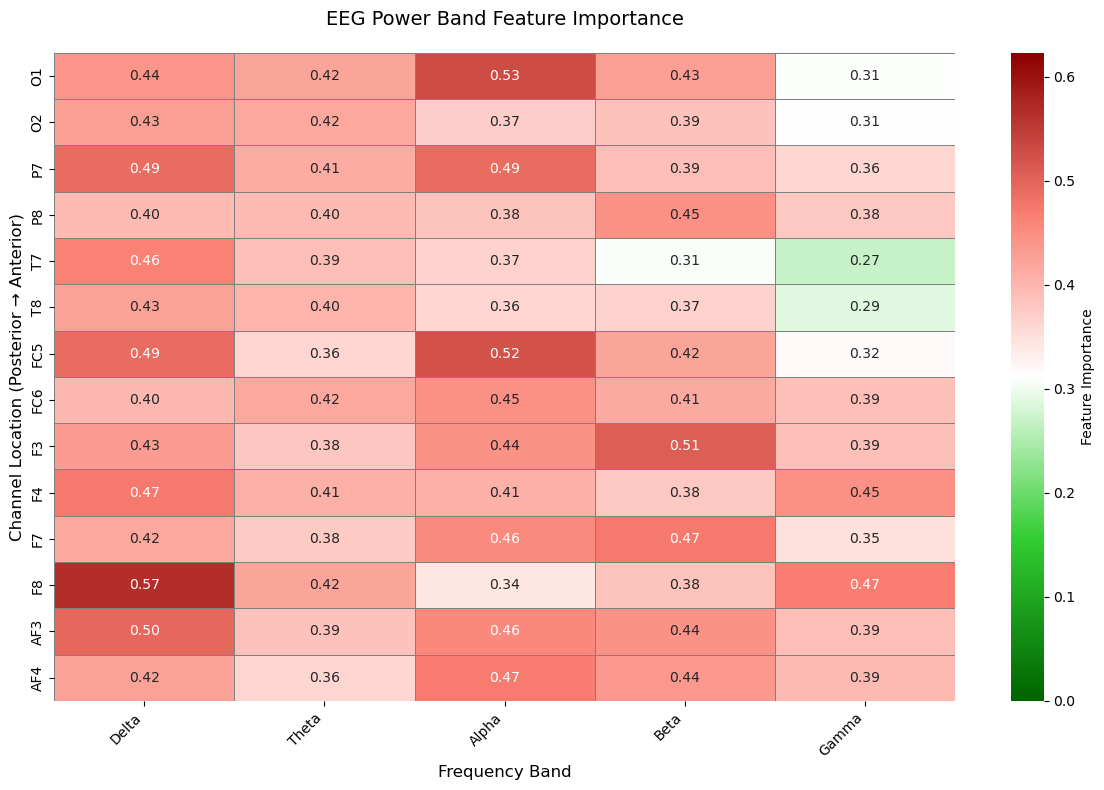

In [57]:
###### Making a heatmap version1: features for both classes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Load your data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\average_feature_importance_q1_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter for power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract channel and band information
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(
    lambda x: pd.Series(extract_components(x)))

# Define proper ordering
channel_order = ['O1', 'O2', 'P7', 'P8', 'T7', 'T8', 
                'FC5', 'FC6', 'F3', 'F4', 'F7', 'F8', 'AF3', 'AF4']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table
heatmap_df = power_features.groupby(['Channel', 'Band'])['Mean_Absolute_Weight'].mean().reset_index()
pivot_df = heatmap_df.pivot(index='Channel', columns='Band', values='Mean_Absolute_Weight')
pivot_df = pivot_df.reindex(index=channel_order, columns=band_order)

# Create vibrant colormap
colors = ["darkgreen", "limegreen", "white", "salmon", "darkred"]
cmap = LinearSegmentedColormap.from_list("vibrant", colors, N=256)

# Create figure with white background
plt.figure(figsize=(12, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot heatmap with colors
sns.heatmap(
    pivot_df,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Feature Importance'},
    vmin=0,
    vmax=pivot_df.max().max() * 1.1  # Slightly above max value
)

# Formatting
plt.title('EEG Power Band Feature Importance', pad=20, fontsize=14)
plt.xlabel('Frequency Band', fontsize=12)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save and show
output_path = os.path.join(output_dir, "power_features_heatmap_colored.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Heatmap with colors saved to: {output_path}")
plt.show()

In [59]:
############### weights analysis version 2: class 0 and class 1 seperately
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\feature_weights_q1_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load and convert feature names as before
weights_df = pd.read_csv(weights_path)
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate statistics with class direction interpretation
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count'],
}).reset_index()

# Flatten columns
feature_importance.columns = [
    'Feature', 
    'Mean_Absolute_Weight', 'Std_Absolute_Weight',
    'Mean_Weight', 'Std_Weight', 'Participant_Count'
]

# Add class interpretation columns
feature_importance['Direction'] = feature_importance['Mean_Weight'].apply(
    lambda x: 'Emotional (Class 1)' if x > 0 else 'Neutral (Class 0)'
)
feature_importance['Effect_Size'] = feature_importance['Mean_Absolute_Weight']

# Sort by importance
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print formatted table
print("\nFeature Weights by Class Contribution:")
print(feature_importance[['Feature', 'Mean_Weight', 'Direction', 'Effect_Size']].to_string(index=False))

# Save full results
output_path = os.path.join(output_dir, "feature_weights_with_class_interpretation.csv")
feature_importance.to_csv(output_path, index=False)
print(f"\nResults saved to {output_path}")

# Enhanced visualization
plt.figure(figsize=(14, 10))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

# Color by direction
colors = ['red' if x > 0 else 'green' for x in top_features['Mean_Weight']]

plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         color=colors, alpha=0.7,
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5, edgecolor='black')

# Add annotations
for i, (_, row) in enumerate(top_features.iterrows()):
    plt.text(0.05, i, 
             f"{'↑Emo' if row['Mean_Weight'] > 0 else '↓Neu'} ({row['Mean_Weight']:.2f})",
             va='center', ha='left', color='white', fontweight='bold')

plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Predictive Features\n(Red=Emotional, Green=Neutral)', pad=20)
plt.xlabel('Mean Absolute Weight (Effect Size)')
plt.ylabel('EEG Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(output_dir, "feature_weights_class_direction.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Directional plot saved to {plot_path}")
plt.close()


Feature Weights by Class Contribution:
                    Feature  Mean_Weight           Direction  Effect_Size
   Channel F8 - Delta Power     0.135658 Emotional (Class 1)     0.566581
Channel FC6 - theta Entropy     0.131741 Emotional (Class 1)     0.535243
   Channel O1 - Alpha Power     0.034098 Emotional (Class 1)     0.528557
 Channel F7 - theta Entropy    -0.066035   Neutral (Class 0)     0.522127
  Channel FC5 - Alpha Power    -0.137187   Neutral (Class 0)     0.521226
Channel AF3 - theta Entropy    -0.099295   Neutral (Class 0)     0.519163
    Channel F3 - Beta Power    -0.086286   Neutral (Class 0)     0.508749
  Channel AF3 - Delta Power     0.028784 Emotional (Class 1)     0.495647
 Channel F4 - alpha Entropy    -0.064492   Neutral (Class 0)     0.492279
   Channel P7 - Delta Power    -0.052406   Neutral (Class 0)     0.491039
   Channel P7 - Alpha Power    -0.165310   Neutral (Class 0)     0.490429
  Channel FC5 - Delta Power    -0.104780   Neutral (Class 0)     0.49012

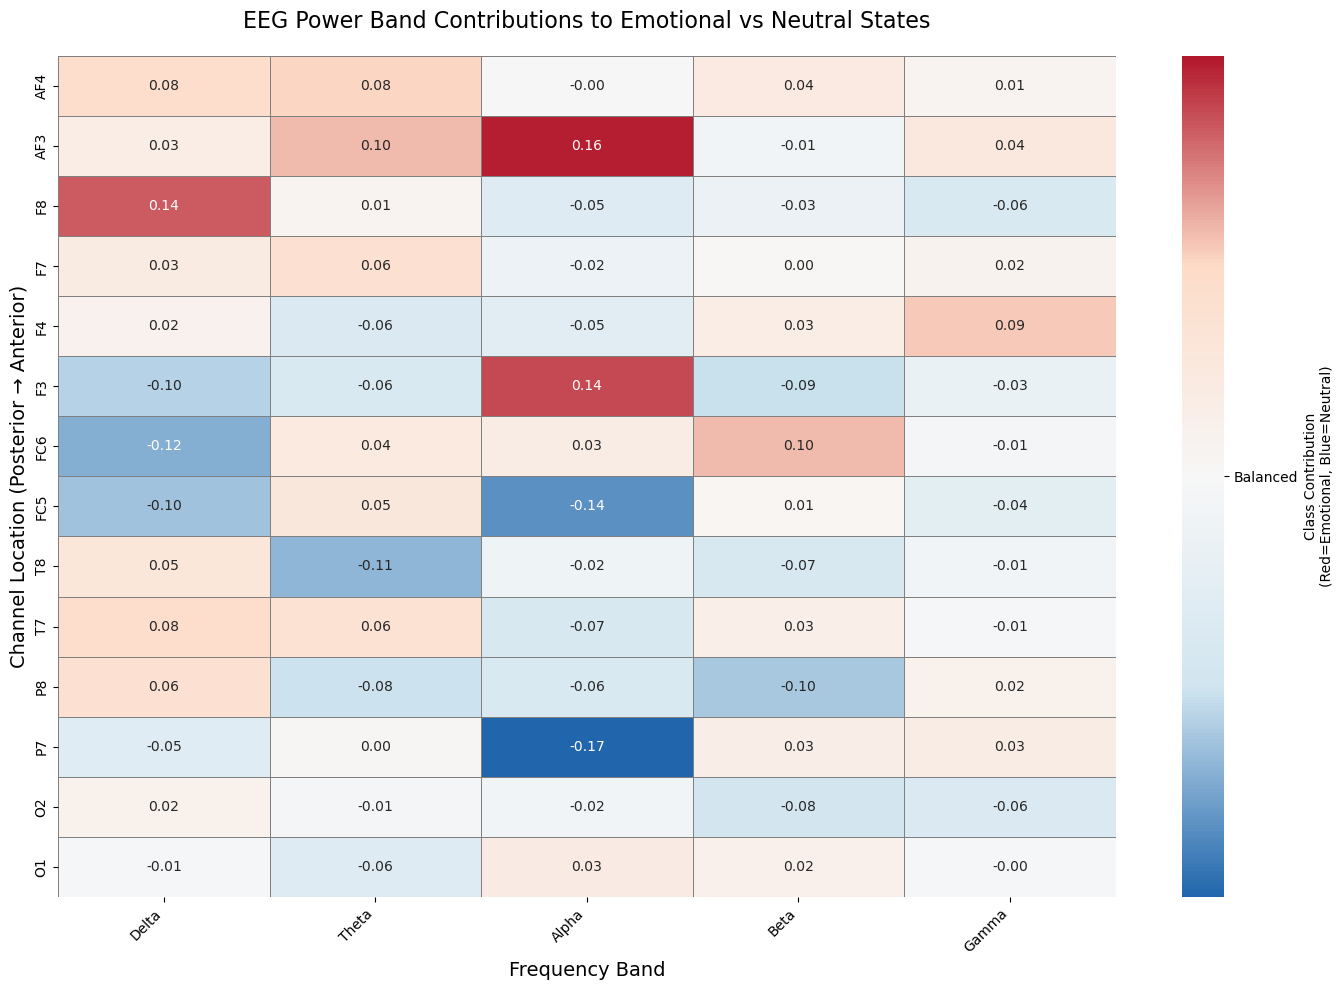

In [61]:
###### Making a heatmap version1: features for both classes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

############### weights analysis version 2: heatmap 
# Load your data - now including Mean_Weight for direction
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\average_feature_importance_q1_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract components
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(lambda x: pd.Series(extract_components(x)))

# Neuroanatomical channel order (anterior → posterior)
channel_order = ['AF4', 'AF3', 'F8', 'F7', 'F4', 'F3', 'FC6', 'FC5', 'T8', 'T7', 'P8', 'P7', 'O2', 'O1']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table for SIGNED weights (direction matters)
pivot_df = power_features.pivot_table(
    index='Channel',
    columns='Band',
    values='Mean_Weight',  # Using signed weights for color direction
    aggfunc='mean'
).reindex(index=channel_order, columns=band_order)

# Enhanced colormap
colors = ["#2166ac", "#d1e5f0", "#f7f7f7", "#fddbc7", "#b2182b"]  # Strong blue to white to strong red
cmap = LinearSegmentedColormap.from_list("diverging", colors, N=256)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    pivot_df,
    cmap=cmap,
    center=0,  # Critical for diverging colormap
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={
        'label': 'Class Contribution\n(Red=Emotional, Blue=Neutral)', 
        'ticks': [-1, -0.5, 0, 0.5, 1]  # Adjust based on your weight range
    },
    vmin=-max(abs(pivot_df.min().min()), pivot_df.max().max()),
    vmax=max(abs(pivot_df.min().min()), pivot_df.max().max())
)

# Formatting
plt.title('EEG Power Band Contributions to Emotional vs Neutral States', pad=20, fontsize=16)
plt.xlabel('Frequency Band', fontsize=14)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add colorbar interpretation
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['Strong Neutral', 'Neutral', 'Balanced', 'Emotional', 'Strong Emotional'])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "emotion_neutral_contributions.png"), dpi=300, bbox_inches='tight')
plt.show()

## Tests for all data, not just neural, from v5

Descriptive Statistics:
Original Data (macro avg):
count    70.000000
mean      0.818444
std       0.042884
min       0.690616
25%       0.792196
50%       0.819337
75%       0.849269
max       0.906469
Name: F1, dtype: float64

Permuted Data (macro avg):
count    70.000000
mean      0.500539
std       0.049114
min       0.383124
25%       0.473790
50%       0.498239
75%       0.531602
max       0.597990
Name: F1, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9893, p=0.8159
Permuted Data: W=0.9773, p=0.2325


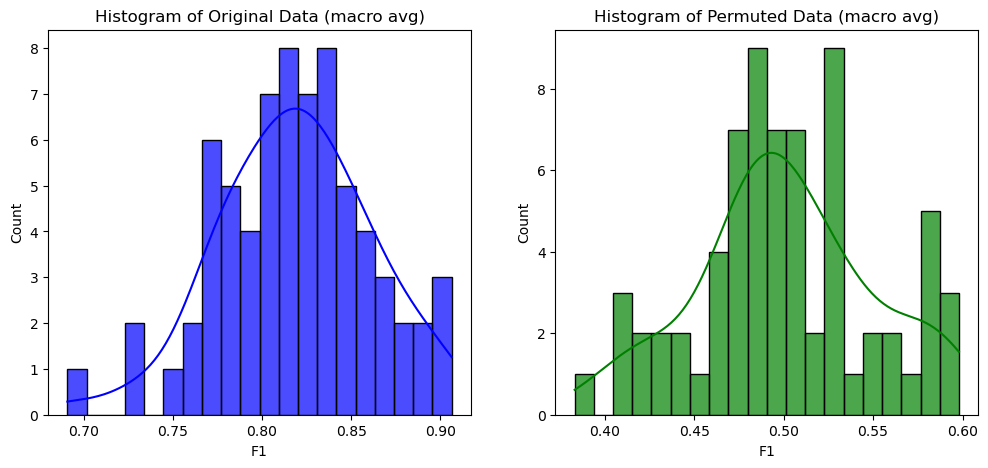

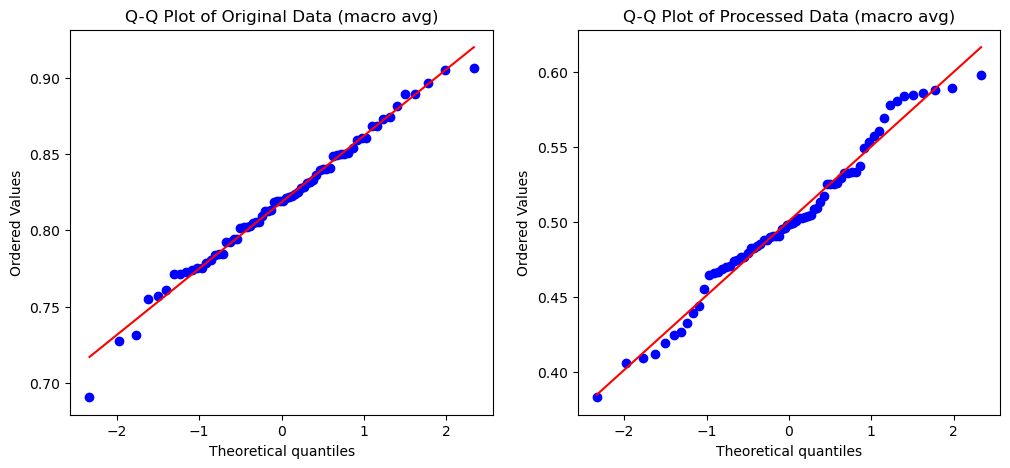


Paired t-test results:
T-statistic: 38.5507
P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant.

Permutation Test Results:
Observed Mean Difference: 0.3179
Permutation P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).


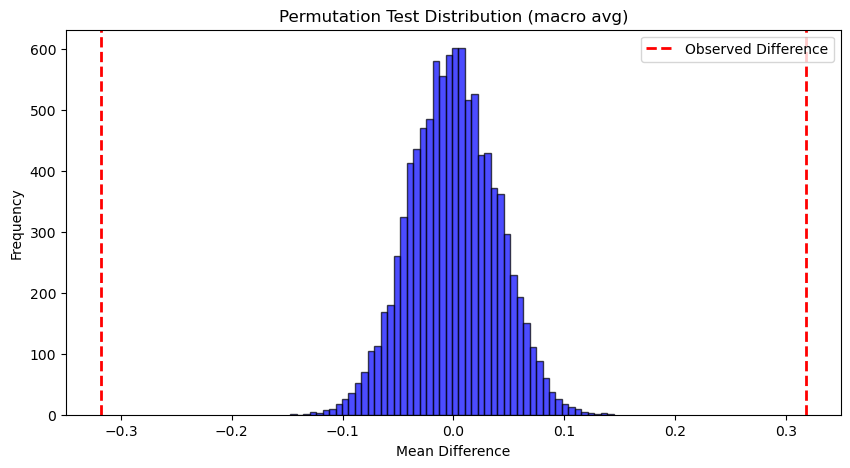

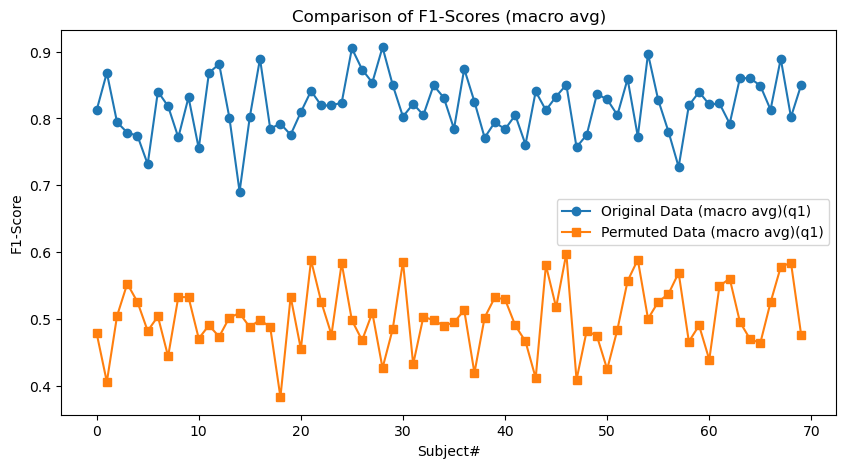

In [63]:
############ Quick t-test and permutation test
########### Q1 ###############
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_q1_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_q1_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)

# Print results
print("\nPaired t-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
        
# Interpret results
alpha = 0.05
if p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant.")
else:
    print("No significant difference in F1-Scores (macro avg) between the two files.")

# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

if perm_p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()



Participants with F1 = 1:
['corrected_32_processed_final', 'corrected_42_processed_final', 'corrected_39_processed_final', 'corrected_37_processed_final', 'corrected_26_processed_final', 'corrected_16_processed_final', 'corrected_63_processed_final']
Descriptive Statistics:
Original Data (macro avg):
count    62.000000
mean      0.827858
std       0.049935
min       0.690616
25%       0.796659
50%       0.828534
75%       0.855204
max       0.968050
Name: F1, dtype: float64

Permuted Data (macro avg):
count    62.000000
mean      0.497936
std       0.047245
min       0.390211
25%       0.463024
50%       0.500261
75%       0.525744
max       0.648851
Name: F1, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9911, p=0.9356
Permuted Data: W=0.9819, p=0.4917


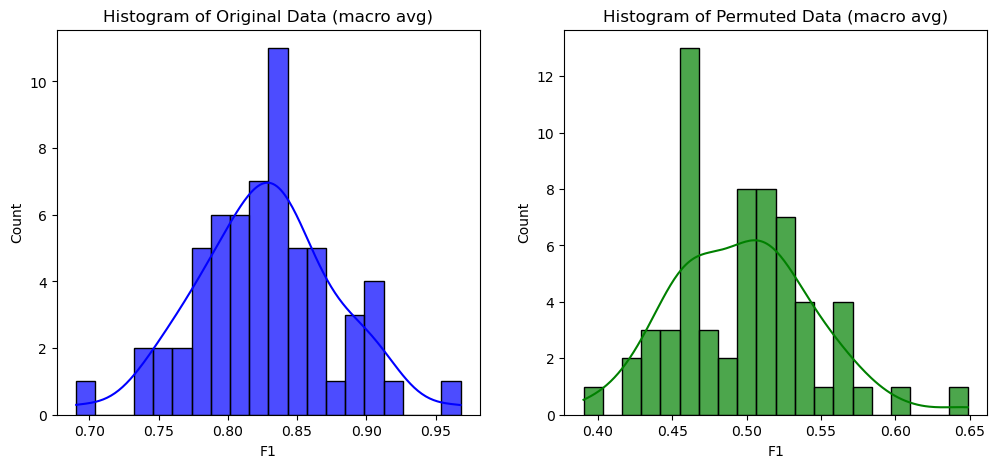

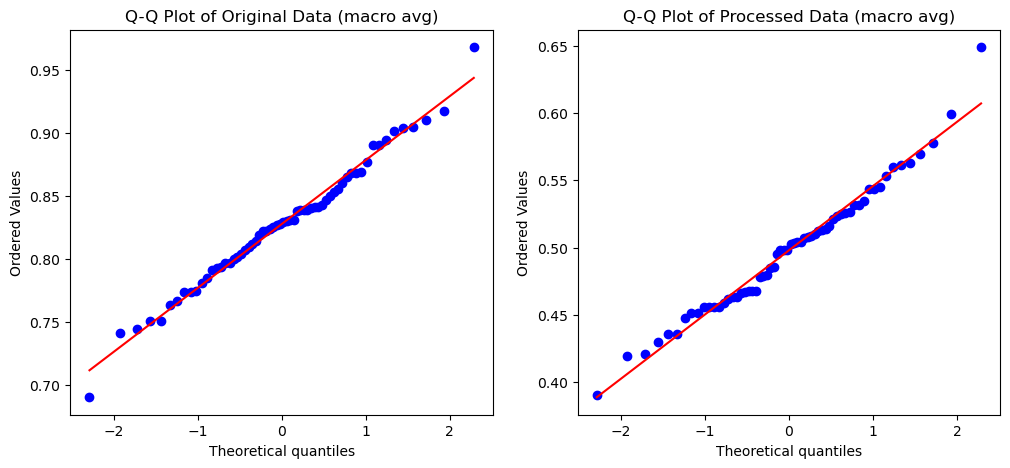


Paired t-test results:
T-statistic: 38.1305
P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant.

Permutation Test Results:
Observed Mean Difference: 0.3299
Permutation P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).


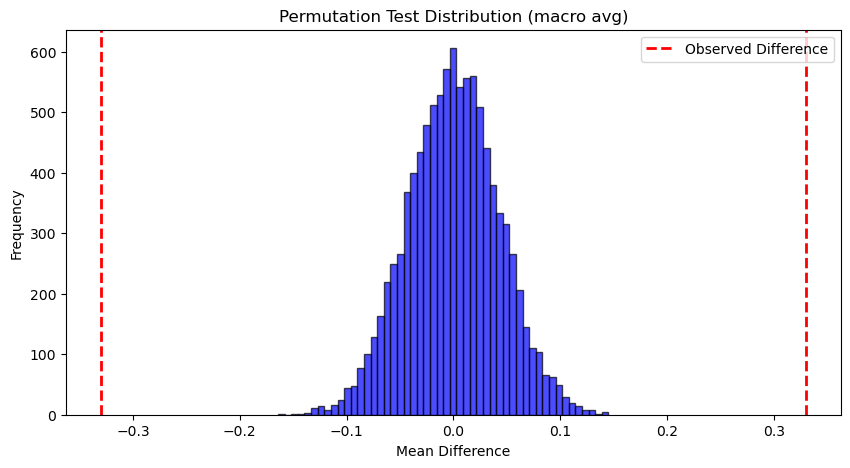

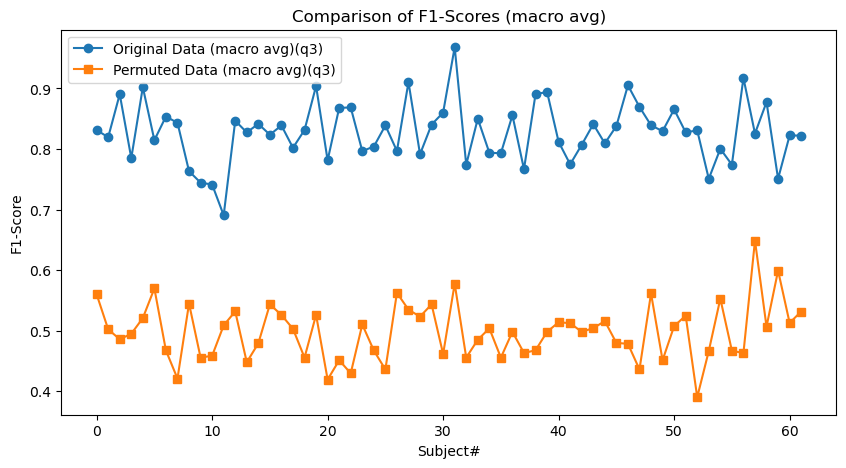

In [65]:
############ Quick t-test and permutation test
########### Q3 ############
######## Notes on weird data: subjects had F1 of 1:63, 37, 42, 16, 32, 39, 26
#Participants with F1 = 1:
#[63(class0:3), 37(class1:6), 42(class0:7), 16(class0:2), 32(class1:3), 39(class1:3), 26(class1:5)]

import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_q3_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_q3_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
metric_col = "Class"
subject_col = "Participant" 
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# ====== NEW STEP: Find and remove participants with F1 == 1 ======
participants_with_f1_1 = df1_macro[df1_macro[f1_col] == 1]

if not participants_with_f1_1.empty:
    print("\nParticipants with F1 = 1:")
    print(participants_with_f1_1['Participant'].tolist())

    # Remove these participants
    subjects_to_remove = participants_with_f1_1['Participant'].tolist()
    df1_macro = df1_macro[~df1_macro['Participant'].isin(subjects_to_remove)].copy()
    df2_macro = df2_macro[~df2_macro['Participant'].isin(subjects_to_remove)].copy()
else:
    print("\nNo participants had F1 = 1.")
    
# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)

# Print results
print("\nPaired t-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
        
# Interpret results
alpha = 0.05
if p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant.")
else:
    print("No significant difference in F1-Scores (macro avg) between the two files.")

# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

if perm_p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()



Participants with F1 = 1:
['corrected_17_processed_final']
Descriptive Statistics:
Original Data (macro avg):
count    69.000000
mean      0.814064
std       0.044953
min       0.711965
25%       0.781696
50%       0.810787
75%       0.843223
max       0.923571
Name: F1, dtype: float64

Permuted Data (macro avg):
count    69.000000
mean      0.496496
std       0.046997
min       0.359958
25%       0.469489
50%       0.500308
75%       0.532343
max       0.580392
Name: F1, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9840, p=0.5223
Permuted Data: W=0.9804, p=0.3511


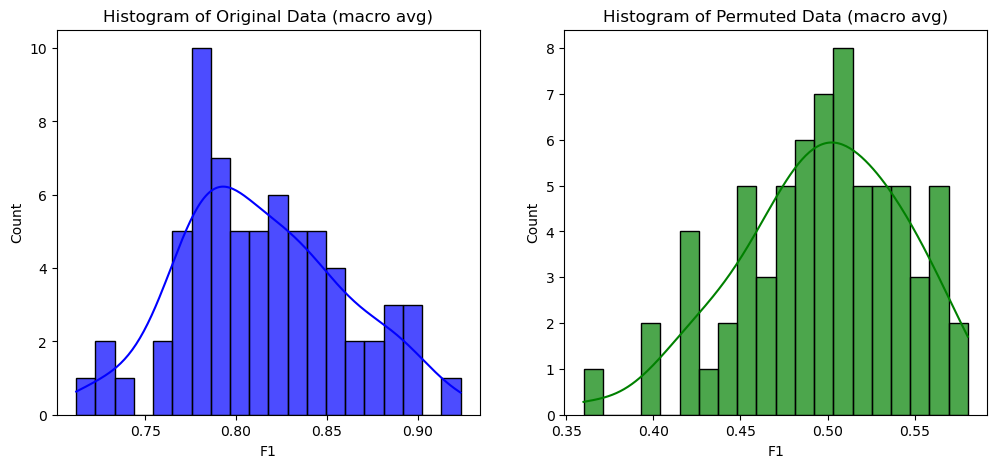

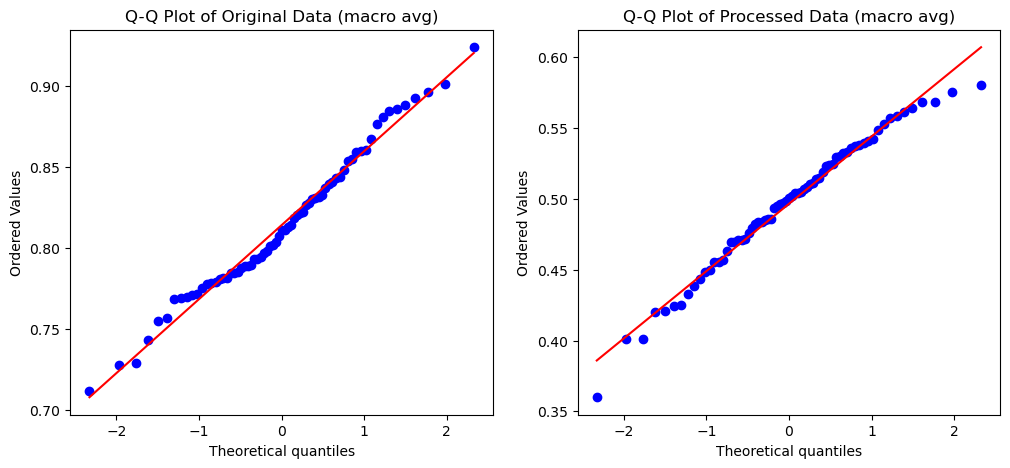


Paired t-test results:
T-statistic: 39.2204
P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant.

Permutation Test Results:
Observed Mean Difference: 0.3176
Permutation P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).


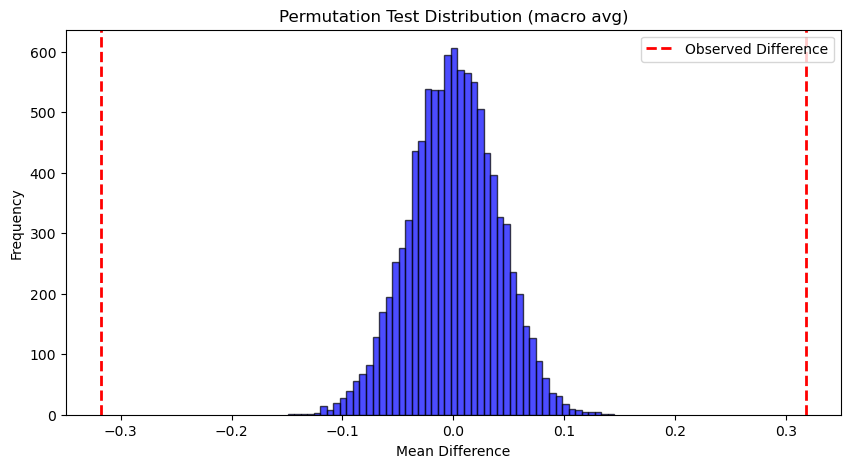

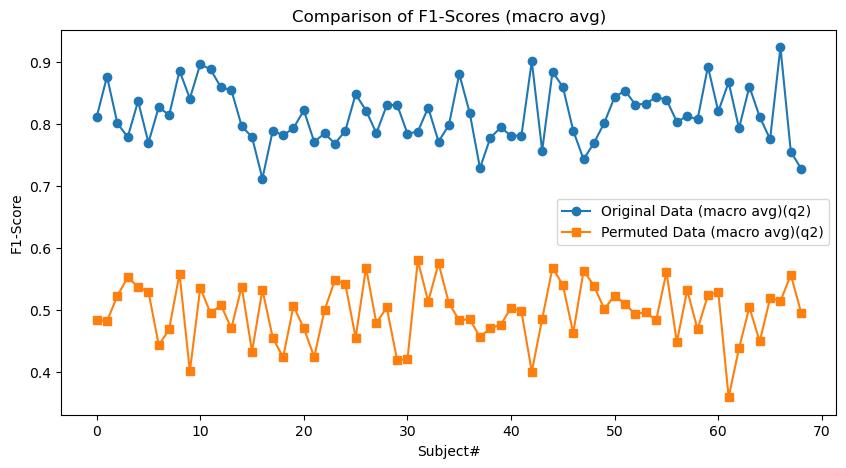

In [67]:
############ Quick t-test and permutation test
########### Q2 ###########
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_q2_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_q2_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
metric_col = "Class"
subject_col = "Participant" 
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# ====== NEW STEP: Find and remove participants with F1 == 1 ======
participants_with_f1_1 = df1_macro[df1_macro[f1_col] == 1]

if not participants_with_f1_1.empty:
    print("\nParticipants with F1 = 1:")
    print(participants_with_f1_1['Participant'].tolist())

    # Remove these participants
    subjects_to_remove = participants_with_f1_1['Participant'].tolist()
    df1_macro = df1_macro[~df1_macro['Participant'].isin(subjects_to_remove)].copy()
    df2_macro = df2_macro[~df2_macro['Participant'].isin(subjects_to_remove)].copy()
else:
    print("\nNo participants had F1 = 1.")
    
# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)

# Print results
print("\nPaired t-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
        
# Interpret results
alpha = 0.05
if p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant.")
else:
    print("No significant difference in F1-Scores (macro avg) between the two files.")

# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

if perm_p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()


Descriptive Statistics:
Original Data (macro avg):
count    70.000000
mean      0.815459
std       0.048321
min       0.691198
25%       0.791312
50%       0.819337
75%       0.847470
max       0.923297
Name: F1, dtype: float64

Permuted Data (macro avg):
count    70.000000
mean      0.496995
std       0.040014
min       0.399706
25%       0.469316
50%       0.495729
75%       0.524573
max       0.640672
Name: F1, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9836, p=0.4945
Permuted Data: W=0.9755, p=0.1863


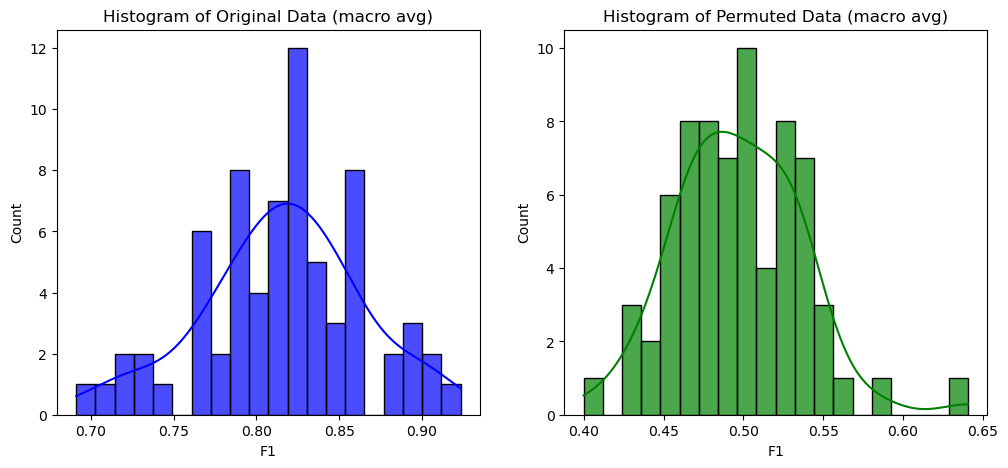

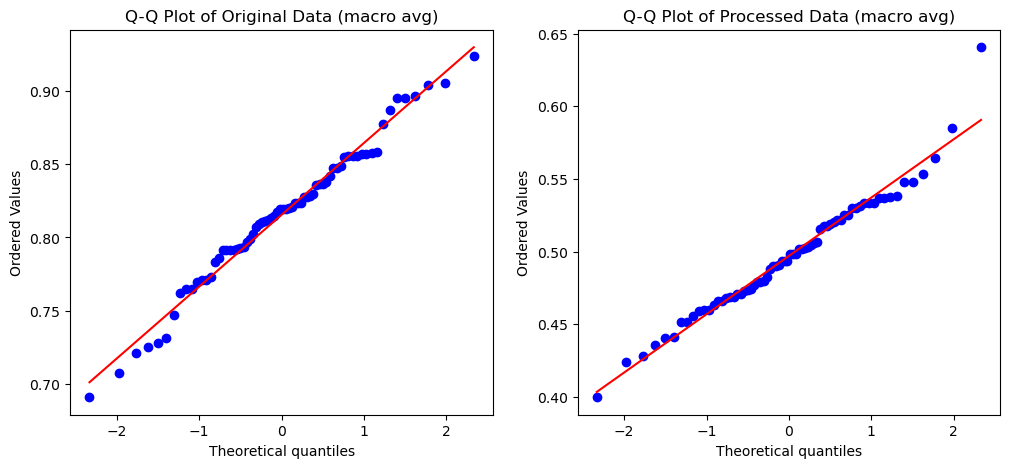


Paired t-test results:
T-statistic: 47.0576
P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant.

Permutation Test Results:
Observed Mean Difference: 0.3185
Permutation P-value: 0.0000
The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).


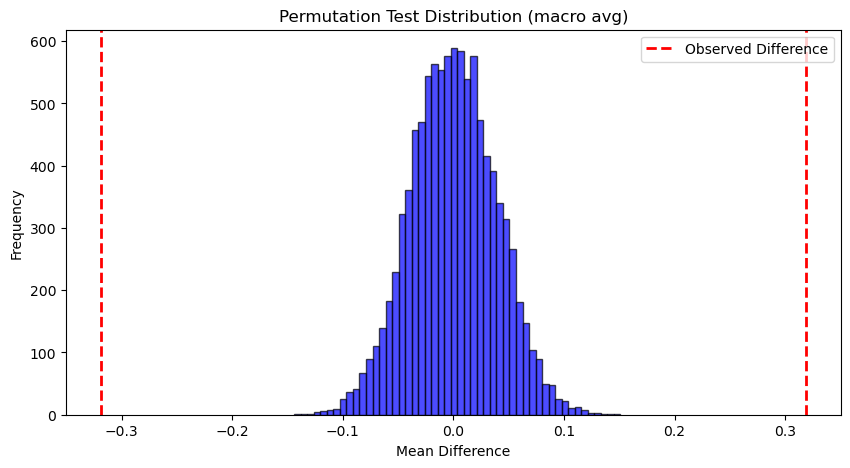

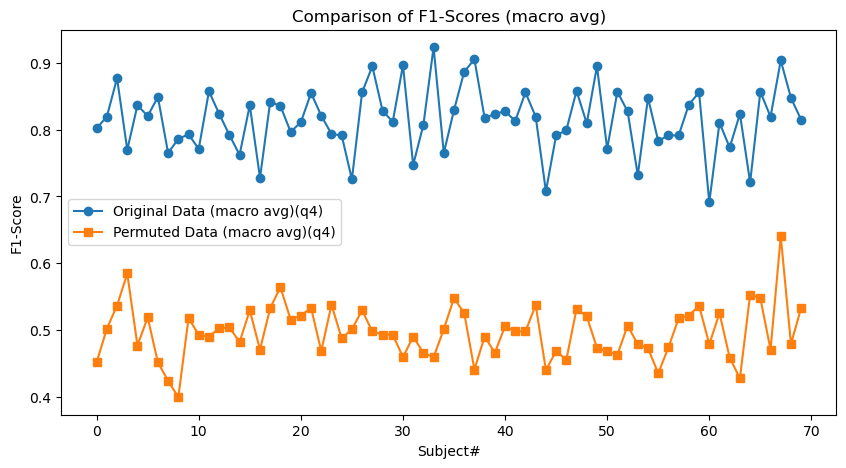

In [69]:
############ Quick t-test and permutation test
########### Q4 ##########
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)

# Print results
print("\nPaired t-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
        
# Interpret results
alpha = 0.05
if p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant.")
else:
    print("No significant difference in F1-Scores (macro avg) between the two files.")

# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

if perm_p_value < alpha:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()


########## Feature Importance for Facial Expression only Features

In [42]:
#### Facial Expression only model, feature importance, q1 emotion perception
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from matplotlib.colors import LinearSegmentedColormap

# =========================
# Paths (facial expression)
# =========================
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\facial expression only\feature_weights_expression_q1_y_original.csv"
output_dir   = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\facial expression only"
os.makedirs(output_dir, exist_ok=True)

# =========================
# Load weights (same schema as EEG version)
# Expected columns: Participant, Feature, Weight, Absolute_Weight
# =========================
weights_df = pd.read_csv(weights_path)

# =========================
# Compute per-feature stats (no EEG channel mapping needed)
# =========================
feature_importance = (
    weights_df
    .groupby('Feature', as_index=False)
    .agg(Mean_Absolute_Weight=('Absolute_Weight','mean'),
         Std_Absolute_Weight=('Absolute_Weight','std'),
         Mean_Weight=('Weight','mean'),
         Std_Weight=('Weight','std'),
         Participant_Count=('Weight','count'))
    .sort_values('Mean_Absolute_Weight', ascending=False)
)

print("\nAverage Feature Weights Across All Participants (Ranked by Importance):")
print(feature_importance.to_string(index=False))

# Save table
importance_csv_path = os.path.join(output_dir, "average_feature_importance_expression_q1_y_original.csv")
feature_importance.to_csv(importance_csv_path, index=False)
print(f"\nAverage feature importance saved to {importance_csv_path}")

# =========================
# Top-N bar chart (absolute weights)
# =========================
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         xerr=top_features['Std_Absolute_Weight'], capsize=5)
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Predictive Facial Expression Features\n(Average Absolute Weights ± SD)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()

bar_path = os.path.join(output_dir, "top_features_plot_expression_q1_y_original.png")
plt.savefig(bar_path, dpi=300, bbox_inches='tight')
print(f"Feature importance plot saved to {bar_path}")
plt.close()

# =========================
# HEATMAP (signed Mean_Weight) for the 9 expression features
# We parse "Feature" strings like "Happy" or "Happy - Intensity"
# into Base = emotion/construct, Metric = 'Intensity' (default) or parsed suffix.
# =========================
EMOTION_ORDER = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]
EMOTION_SET = set(EMOTION_ORDER)

def parse_expression_feature(name: str):
    parts = [p.strip() for p in name.split(' - ')]
    base = parts[0].title()  # normalize capitalization
    metric = parts[1] if len(parts) > 1 else "Intensity"
    # normalize a few common variants
    normalize = {
        "Happiness": "Happy",
        "Sadness": "Sad",
        "Anger": "Angry",
        "Surprise": "Surprised",
        "Fear": "Scared",
        "Disgust": "Disgusted"
    }
    base = normalize.get(base, base)
    return base, metric

# Parse components
parsed = feature_importance['Feature'].apply(parse_expression_feature)
feature_importance[['Base', 'Metric']] = pd.DataFrame(parsed.tolist(), index=feature_importance.index)

# Keep only the 9 facial-expression predictors
expr_df = feature_importance[feature_importance['Base'].isin(EMOTION_SET)].copy()
if expr_df.empty:
    print("No facial-expression features found among the nine specified — skipping heatmap.")
else:
    # Row order (as given)
    expr_df['Base'] = pd.Categorical(expr_df['Base'], categories=EMOTION_ORDER, ordered=True)

    # Column (metric) order by frequency (e.g., Intensity, Mean, Velocity, etc.)
    metric_order = expr_df['Metric'].value_counts().index.tolist()

    # Pivot signed weights
    pivot_df = expr_df.pivot_table(index='Base', columns='Metric', values='Mean_Weight', aggfunc='mean')
    pivot_df = pivot_df.reindex(index=EMOTION_ORDER)  # ensure desired row order
    pivot_df = pivot_df.reindex(columns=metric_order) # consistent column order

    # Diverging colormap centered at 0
    vmax = np.nanmax(np.abs(pivot_df.values)) if pivot_df.size else 1.0
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0  # fallback to avoid zero range

    colors = ["#2166ac", "#d1e5f0", "#f7f7f7", "#fddbc7", "#b2182b"]
    cmap = LinearSegmentedColormap.from_list("diverging", colors, N=256)

    plt.figure(figsize=(max(8, 1.2*len(metric_order)), max(6, 0.6*len(pivot_df))))
    ax = sns.heatmap(pivot_df, cmap=cmap, center=0, annot=True, fmt=".2f",
                     linewidths=0.5, linecolor='gray',
                     vmin=-vmax, vmax=vmax,
                     cbar_kws={'label': 'Class Contribution\n(Red = Emotional, Blue = Neutral)'})
    plt.title('Facial Expression Feature Contributions (Signed Mean Weights)', pad=18, fontsize=14)
    plt.xlabel('Metric')
    plt.ylabel('Feature')
    plt.tight_layout()

    heatmap_path = os.path.join(output_dir, "heatmap_expression_contributions.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {heatmap_path}")
    plt.close()

# =========================
# Additional sanity checks
# =========================
print("\nAdditional Analysis:")
print(f"Total number of features: {len(feature_importance)}")
print(f"Number of participants: {weights_df['Participant'].nunique()}")
print(f"Features present in all participants: {sum(feature_importance['Participant_Count'] == feature_importance['Participant_Count'].max())}")



Average Feature Weights Across All Participants (Ranked by Importance):
  Feature  Mean_Absolute_Weight  Std_Absolute_Weight  Mean_Weight  Std_Weight  Participant_Count
    Happy              0.437944             0.423254    -0.223880    0.568216                 70
  Valence              0.428497             0.492250     0.050631    0.652672                 70
Disgusted              0.400045             0.561517     0.004252    0.691114                 70
  Neutral              0.389011             0.467310    -0.029595    0.609109                 70
    Angry              0.337782             0.398558     0.061502    0.520347                 70
Surprised              0.322889             0.291309    -0.138856    0.413605                 70
      Sad              0.300769             0.353727     0.033960    0.464463                 70
   Scared              0.296948             0.303626     0.097402    0.414753                 70
  Arousal              0.281816             0.354599  

C:\Users\OLten\AppData\Local\Temp\ipykernel_1236\2089030.py:104: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = expr_df.pivot_table(index='Base', columns='Metric', values='Mean_Weight', aggfunc='mean')


Heatmap saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\facial expression only\heatmap_expression_contributions.png

Additional Analysis:
Total number of features: 9
Number of participants: 70
Features present in all participants: 9


In [46]:
#### Facial Expression only model, feature importance, q3 emotion perception
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from matplotlib.colors import LinearSegmentedColormap

# =========================
# Paths (facial expression)
# =========================
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only\feature_weights_expression_q3_y_original.csv"
output_dir   = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only"
os.makedirs(output_dir, exist_ok=True)

# =========================
# Load weights (same schema as EEG version)
# Expected columns: Participant, Feature, Weight, Absolute_Weight
# =========================
weights_df = pd.read_csv(weights_path)

# =========================
# Compute per-feature stats (no EEG channel mapping needed)
# =========================
feature_importance = (
    weights_df
    .groupby('Feature', as_index=False)
    .agg(Mean_Absolute_Weight=('Absolute_Weight','mean'),
         Std_Absolute_Weight=('Absolute_Weight','std'),
         Mean_Weight=('Weight','mean'),
         Std_Weight=('Weight','std'),
         Participant_Count=('Weight','count'))
    .sort_values('Mean_Absolute_Weight', ascending=False)
)

print("\nAverage Feature Weights Across All Participants (Ranked by Importance):")
print(feature_importance.to_string(index=False))

# Save table
importance_csv_path = os.path.join(output_dir, "average_feature_importance_expression_q3_y_original.csv")
feature_importance.to_csv(importance_csv_path, index=False)
print(f"\nAverage feature importance saved to {importance_csv_path}")

# =========================
# Top-N bar chart (absolute weights)
# =========================
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         xerr=top_features['Std_Absolute_Weight'], capsize=5)
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Predictive Facial Expression Features\n(Average Absolute Weights ± SD)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()

bar_path = os.path.join(output_dir, "top_features_plot_expression_q3_y_original.png")
plt.savefig(bar_path, dpi=300, bbox_inches='tight')
print(f"Feature importance plot saved to {bar_path}")
plt.close()

# =========================
# HEATMAP (signed Mean_Weight) for the 9 expression features
# We parse "Feature" strings like "Happy" or "Happy - Intensity"
# into Base = emotion/construct, Metric = 'Intensity' (default) or parsed suffix.
# =========================
EMOTION_ORDER = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]
EMOTION_SET = set(EMOTION_ORDER)

def parse_expression_feature(name: str):
    parts = [p.strip() for p in name.split(' - ')]
    base = parts[0].title()  # normalize capitalization
    metric = parts[1] if len(parts) > 1 else "Intensity"
    # normalize a few common variants
    normalize = {
        "Happiness": "Happy",
        "Sadness": "Sad",
        "Anger": "Angry",
        "Surprise": "Surprised",
        "Fear": "Scared",
        "Disgust": "Disgusted"
    }
    base = normalize.get(base, base)
    return base, metric

# Parse components
parsed = feature_importance['Feature'].apply(parse_expression_feature)
feature_importance[['Base', 'Metric']] = pd.DataFrame(parsed.tolist(), index=feature_importance.index)

# Keep only the 9 facial-expression predictors
expr_df = feature_importance[feature_importance['Base'].isin(EMOTION_SET)].copy()
if expr_df.empty:
    print("No facial-expression features found among the nine specified — skipping heatmap.")
else:
    # Row order (as given)
    expr_df['Base'] = pd.Categorical(expr_df['Base'], categories=EMOTION_ORDER, ordered=True)

    # Column (metric) order by frequency (e.g., Intensity, Mean, Velocity, etc.)
    metric_order = expr_df['Metric'].value_counts().index.tolist()

    # Pivot signed weights
    pivot_df = expr_df.pivot_table(index='Base', columns='Metric', values='Mean_Weight', aggfunc='mean')
    pivot_df = pivot_df.reindex(index=EMOTION_ORDER)  # ensure desired row order
    pivot_df = pivot_df.reindex(columns=metric_order) # consistent column order

    # Diverging colormap centered at 0
    vmax = np.nanmax(np.abs(pivot_df.values)) if pivot_df.size else 1.0
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0  # fallback to avoid zero range

    colors = ["#2166ac", "#d1e5f0", "#f7f7f7", "#fddbc7", "#b2182b"]
    cmap = LinearSegmentedColormap.from_list("diverging", colors, N=256)

    plt.figure(figsize=(max(8, 1.2*len(metric_order)), max(6, 0.6*len(pivot_df))))
    ax = sns.heatmap(pivot_df, cmap=cmap, center=0, annot=True, fmt=".2f",
                     linewidths=0.5, linecolor='gray',
                     vmin=-vmax, vmax=vmax,
                     cbar_kws={'label': 'Class Contribution\n(Red = Emotional, Blue = Neutral)'})
    plt.title('Facial Expression Feature Contributions (Signed Mean Weights)', pad=18, fontsize=14)
    plt.xlabel('Metric')
    plt.ylabel('Feature')
    plt.tight_layout()

    heatmap_path = os.path.join(output_dir, "heatmap_expression_contributions.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {heatmap_path}")
    plt.close()

# =========================
# Additional sanity checks
# =========================
print("\nAdditional Analysis:")
print(f"Total number of features: {len(feature_importance)}")
print(f"Number of participants: {weights_df['Participant'].nunique()}")
print(f"Features present in all participants: {sum(feature_importance['Participant_Count'] == feature_importance['Participant_Count'].max())}")



Average Feature Weights Across All Participants (Ranked by Importance):
  Feature  Mean_Absolute_Weight  Std_Absolute_Weight  Mean_Weight  Std_Weight  Participant_Count
  Valence              0.405962             0.504625    -0.009856    0.649444                 69
    Happy              0.387581             0.445843    -0.139093    0.575823                 69
Disgusted              0.320362             0.506049     0.032243    0.599310                 69
  Neutral              0.314682             0.471803     0.045933    0.566514                 69
Surprised              0.306811             0.496273    -0.014032    0.584469                 69
      Sad              0.272858             0.384481     0.014366    0.472401                 69
  Arousal              0.239744             0.339713     0.087272    0.407430                 69
   Scared              0.235884             0.319854     0.104600    0.384271                 69
    Angry              0.231539             0.296987  

C:\Users\OLten\AppData\Local\Temp\ipykernel_1236\1827360519.py:104: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = expr_df.pivot_table(index='Base', columns='Metric', values='Mean_Weight', aggfunc='mean')


Heatmap saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\facial expression only\heatmap_expression_contributions.png

Additional Analysis:
Total number of features: 9
Number of participants: 69
Features present in all participants: 9
